# Module 6 Lab 1

Using SQL and python

In [1]:
# Add two csv tables into pandas
import pandas as pd
o_df = pd.read_csv('store_orders.csv')
c_df = pd.read_csv('store_customers.csv')

In [2]:
o_df.shape

(200, 6)

In [3]:
c_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  40 non-null     int64
 1   name         40 non-null     str  
 2   city         40 non-null     str  
 3   signup_year  40 non-null     int64
dtypes: int64(2), str(2)
memory usage: 2.2 KB


Connect to store.db, pour in orers and customers

Tutorial 1 code

import sqlite3
con = sqlite3.connect("company.db")
df_employees.to_sql("employees", con, index=False)



In [4]:
import sqlite3
con = sqlite3.connect("store.db")
#o_df.to_sql("orders", con, index=False)
#c_df.to_sql("customers", con, index=False)

# Joined tables once then added # to avoid code crashing

In [5]:
pd.read_sql("SELECT name FROM sqlite_master", con)

,name
0,orders
1,customers


In [6]:
#View top 5 rows of orders
pd.read_sql("SELECT * FROM orders LIMIT 5", con)

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


In [7]:
#Filter and sort all rows over $100 sorted by amount highest to lowest
pd.read_sql("SELECT * FROM orders WHERE amount > 100 ORDER BY amount DESC",con)

,order_id,customer_id,product,category,amount,order_date
0,5153,20,dock,electronics,499.00,2026-05-25
1,5140,30,headset,electronics,295.36,2026-05-26
2,5047,901,headset,electronics,293.79,2026-05-15
3,5150,903,monitor,electronics,293.35,2026-06-06
4,5014,6,monitor,electronics,287.83,2026-05-22
...,...,...,...,...,...,...
79,5107,38,shelf,furniture,110.31,2026-05-17
80,5046,13,shelf,furniture,108.47,2026-05-28
81,5009,14,chair,furniture,107.20,2026-05-24
82,5007,36,dock,electronics,103.77,2026-05-21


In [8]:
#Aggregrate by category
#Report for each product category: the number of orders and average order amount (descending)

pd.read_sql("SELECT category, COUNT(*) AS n, AVG(amount) AS avg_amount FROM orders GROUP BY category ORDER BY avg_amount DESC",con)

,category,n,avg_amount
0,electronics,60,190.569500
1,furniture,46,146.251522
2,office,51,30.132549
3,snacks,43,14.619767


The electronics category earns the most orders. There are 60 orders with an average order amount of 190.57 dollars.

In [9]:
#Join for spend by city
#Lecture notes example:
#SELECT c.city, o.order_date, o.amount
#FROM customers c
#INNER JOIN orders o ON c.customer_id = c.customer_id

df= pd.read_sql("SELECT c.city, o.order_date, o.amount FROM orders o JOIN customers c ON o.customer_id = c.customer_id",con)

In [10]:
df.head()

,city,order_date,amount
0,Los Angeles,2026-05-25,14.09
1,Santa Monica,2026-05-08,51.86
2,Venice,2026-06-03,116.25
3,Culver City,2026-05-19,19.72
4,Santa Monica,2026-05-10,284.80


In [11]:
df.shape

(195, 3)

Missing 5 rows, there were 200 before the join (see initial shape query near top of assignment). The data dictionary notes that there are 5 orphaned rows...5 order rows with no customer ids that do not correspond to the customer table. The customer id table holds the city data. Therefore 5 orders do not have city data and 195 rows is a valid number for this query. 

In [13]:
df.groupby('city')['amount'].sum().sort_values(ascending=False).reset_index()

,city,amount
0,Los Angeles,5862.99
1,Culver City,5316.88
2,Santa Monica,4017.93
3,Inglewood,2718.25
4,Torrance,1037.25
5,Venice,462.36


GEMINI USE: I had to search up the part of the code to get it to print in descending order. ".sort_values(ascending=False).reset_index()"

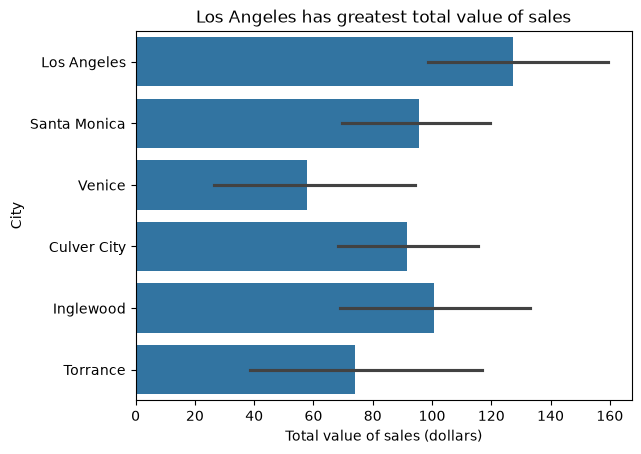

In [21]:
#Create barplot
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=df, x="amount", y="city")
plt.title("Los Angeles has greatest total value of sales")
plt.xlabel("Total value of sales (dollars)")
plt.ylabel("City")
plt.show()

# STEP 8 - My Question



# Step 9
This database holds names, cities, and purchase amounts among other things. I uploaded the customer information. Before releasing publicly, I would remove the name column to protect the customer's private information (city and dollars spent). This is not information that should be in the public realm and is not appropriate for me to send out to the world. 